In [ ]:
!pip install -q ultralytics sahi pandas

In [8]:
import os, shutil, yaml, random, cv2, torch, torchvision
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ultralytics import YOLO
from PIL import Image
from tqdm.auto import tqdm

DATASET_NAME = 'Final_Dataset' 
KAGGLE_INPUT = "/kaggle/input/datasets/zeyadmagdinew/finaldatadetection1/Final_Dataset"
KAGGLE_WORKING = '/kaggle/working/hiero_pro_project'

os.makedirs(KAGGLE_WORKING, exist_ok=True)

✅ Workspace ready: /kaggle/working/hiero_pro_project


In [9]:
def apply_pro_enhancement(img):
    if img is None: return None
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    enhanced = cv2.cvtColor(cv2.merge((l,a,b)), cv2.COLOR_LAB2BGR)
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    return cv2.filter2D(enhanced, -1, kernel)

In [10]:
def slice_image_and_labels(img_path, lbl_path, output_img_dir, output_lbl_dir, slice_size=640, overlap=0.5):
    img = cv2.imread(img_path)
    img = apply_pro_enhancement(img)
    if img is None: return
    h, w, _ = img.shape
    boxes = []
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())
                boxes.append([int((xc-bw/2)*w), int((yc-bh/2)*h), int((xc+bw/2)*w), int((yc+bh/2)*h)])
    
    step = int(slice_size * (1 - overlap))
    slice_count = 0
    for y in range(0, max(1, h - slice_size + 1), step):
        for x in range(0, max(1, w - slice_size + 1), step):
            crop = img[y:y+slice_size, x:x+slice_size]
            crop_lbls = []
            for box in boxes:
                nx1, ny1 = max(x, box[0]), max(y, box[1])
                nx2, ny2 = min(x+slice_size, box[2]), min(y+slice_size, box[3])
                if nx2 > nx1 and ny2 > ny1:
                    area, inter = (box[2]-box[0])*(box[3]-box[1]), (nx2-nx1)*(ny2-ny1)
                    if inter / area > 0.4: 
                        c_xc, c_yc = ((nx1+nx2)/2-x)/slice_size, ((ny1+ny2)/2-y)/slice_size
                        c_w, c_h = (nx2-nx1)/slice_size, (ny2-ny1)/slice_size
                        crop_lbls.append(f"0 {c_xc:.6f} {c_yc:.6f} {c_w:.6f} {c_h:.6f}")
            if crop_lbls:
                base = os.path.splitext(os.path.basename(img_path))[0]
                cv2.imwrite(os.path.join(output_img_dir, f"{base}_s{slice_count}.jpg"), crop)
                with open(os.path.join(output_lbl_dir, f"{base}_s{slice_count}.txt"), 'w') as f:
                    f.write('\n'.join(crop_lbls))
                slice_count += 1


✅ Slicing engine boosted.


In [11]:
FINAL_READY_DIR = '/kaggle/working/dataset_ready'
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(FINAL_READY_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(FINAL_READY_DIR, split, 'labels'), exist_ok=True)

for split in ['train', 'val', 'test']:
    img_dir, lbl_dir = os.path.join(KAGGLE_INPUT, split, 'images'), os.path.join(KAGGLE_INPUT, split, 'labels')
    if not os.path.exists(img_dir): continue
    for fname in tqdm(os.listdir(img_dir), desc=f"Processing {split}"):
        if fname.endswith('.jpg'):
            slice_image_and_labels(os.path.join(img_dir, fname), os.path.join(lbl_dir, os.path.splitext(fname)[0] + '.txt'),
                                 os.path.join(FINAL_READY_DIR, split, 'images'), os.path.join(FINAL_READY_DIR, split, 'labels'))

Processing train:   0%|          | 0/226 [00:00<?, ?it/s]

Processing val:   0%|          | 0/65 [00:00<?, ?it/s]

Processing test:   0%|          | 0/33 [00:00<?, ?it/s]

In [12]:
yaml_data = {'path': FINAL_READY_DIR, 'train': 'train/images', 'val': 'val/images', 'test': 'test/images', 'nc': 1, 'names': ['Sign']}
with open('/kaggle/working/data.yaml', 'w') as f: yaml.dump(yaml_data, f)
print("✅ YAML ready.")

✅ YAML ready.


In [8]:
model = YOLO('yolov8m.pt')
model.train(
    data='/kaggle/working/data.yaml',
    epochs=150, imgsz=640, batch=16, patience=50, optimizer='AdamW', lr0=0.001,
    cos_lr=True, 
    multi_scale=False, 
    mosaic=1.0, mixup=0.3, flipud=0.5, degrees=25.0, 
    translate=0.1, scale=0.5, shear=2.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    project='hieroglyph_85_plus', name='boosted_detector', exist_ok=True
)


Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=25.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=boosted_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79aed81544a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [13]:
RUN_PATH = '/kaggle/working/runs/detect/hieroglyph_85_plus/boosted_detector'
best_model = YOLO("/kaggle/input/models/zeyadmagdinew/yolov8s/pytorch/default/1/iou78Final.pt")

results_data = []
for split in ['train', 'val', 'test']:
    print(f"Validating on {split}...")
    metrics = best_model.val(data='/kaggle/working/data.yaml', split=split, plots=False)
    results_data.append({
        'Split': split.upper(),
        'mAP50': metrics.results_dict['metrics/mAP50(B)'],
        'mAP50-95': metrics.results_dict['metrics/mAP50-95(B)'],
        'Precision': metrics.results_dict['metrics/precision(B)'],
        'Recall': metrics.results_dict['metrics/recall(B)']
    })
df = pd.DataFrame(results_data)
print("\n", df.to_string(index=False))
df.to_csv(os.path.join(RUN_PATH, 'evaluation_summary.csv'), index=False)

--- 📊 FINAL EVALUATION SUMMARY ---
Validating on train...
Ultralytics 8.4.75 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1899.0±437.8 MB/s, size: 174.7 KB)
val: Scanning /kaggle/working/dataset_ready/train/labels... 610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 610/610 1.1Kit/s 0.6s<0.0s
val: /kaggle/working/dataset_ready/train/images/image8_jpg.rf.8286f852ebfa8dd80e1731d4621daf33_s0.jpg: 1 duplicate labels removed
val: New cache created: /kaggle/working/dataset_ready/train/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 3.1it/s 12.4s0.1s
                   all        610       9020      0.875       0.68      0.765      0.488
Speed: 0.6ms preprocess, 15.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Validating on val...
Ultralytics 8.4.75 🚀 

OSError: Cannot save file into a non-existent directory: '/kaggle/working/runs/detect/hieroglyph_85_plus/boosted_detector'

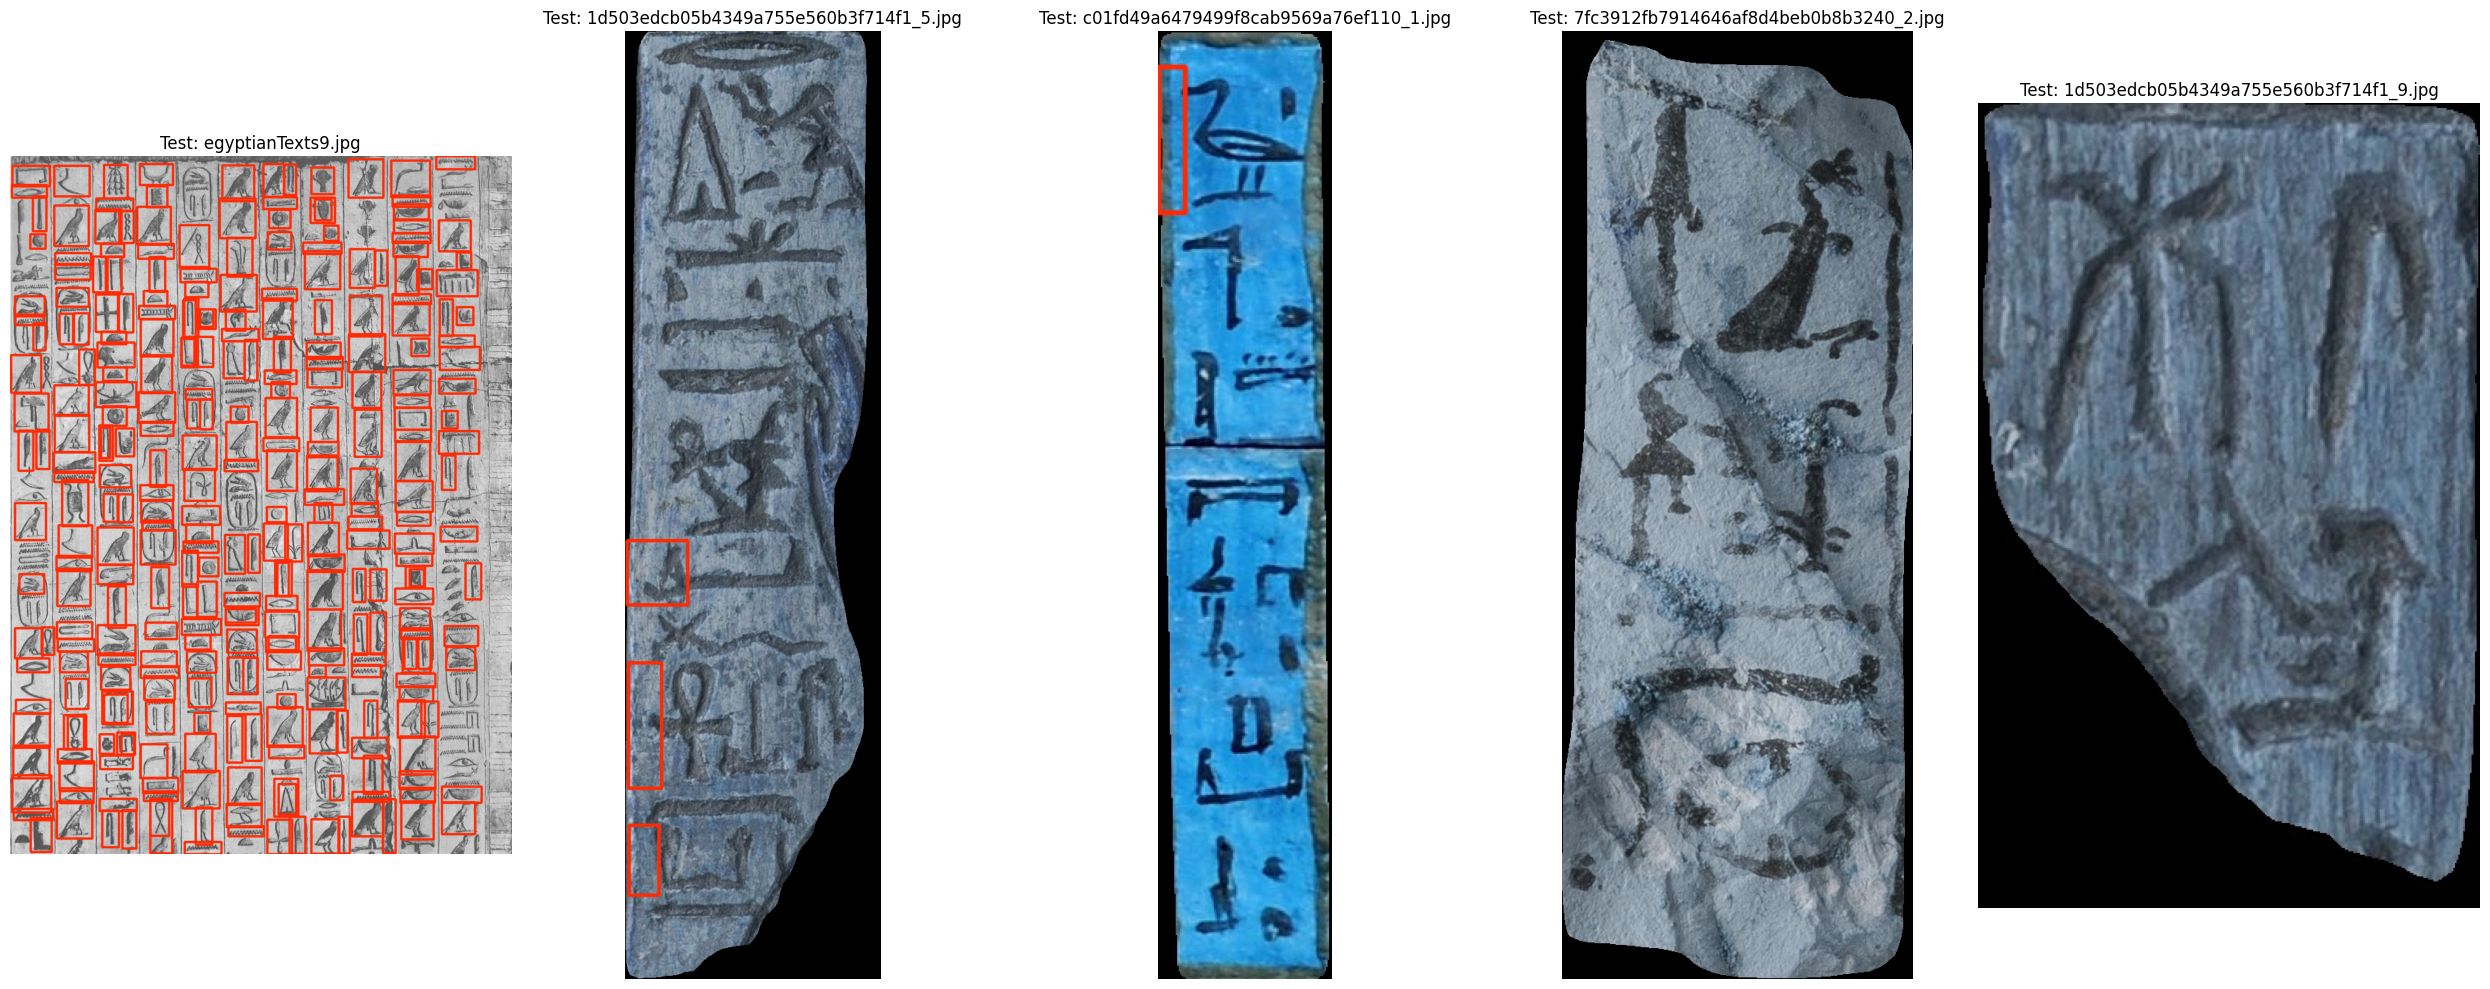

In [ ]:
test_img_dir = os.path.join(FINAL_READY_DIR, 'test/images')
test_imgs = [f for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
if test_imgs:
    sample_test = random.sample(test_imgs, min(5, len(test_imgs)))
    fig, axes = plt.subplots(1, 5, figsize=(25, 10))
    for i, img_name in enumerate(sample_test):
        img_path = os.path.join(test_img_dir, img_name)
        res = best_model.predict(img_path, conf=0.4, augment=True)[0]
        axes[i].imshow(res.plot(labels=False, conf=False))
        axes[i].set_title(f"Test: {img_name}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
import os
import torch
from tqdm import tqdm
from torchvision.ops import box_iou

print("--- 📏 CALCULATING MEAN IoU (mIoU) ---")

total_iou = 0.0
match_count = 0

for img_name in tqdm(test_imgs):

    img_path = os.path.join(test_img_dir, img_name)
    lbl_path = os.path.join(
        FINAL_READY_DIR,
        'test/labels',
        os.path.splitext(img_name)[0] + '.txt'
    )


    import cv2
    img = cv2.imread(img_path)
    if img is None:
        continue

    h, w = img.shape[:2]

    gt_boxes = []

    with open(lbl_path, 'r') as f:
        for line in f:
            _, xc, yc, bw, bh = map(float, line.split())

            xc *= w
            yc *= h
            bw *= w
            bh *= h

            x1 = xc - bw / 2
            y1 = yc - bh / 2
            x2 = xc + bw / 2
            y2 = yc + bh / 2

            gt_boxes.append([x1, y1, x2, y2])

    if len(gt_boxes) == 0:
        continue

    gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32)


    res = best_model.predict(img_path, conf=0.3, verbose=False)[0]
    pred_boxes = res.boxes.xyxy.cpu()

    if len(pred_boxes) == 0:
        continue


    iou_matrix = box_iou(pred_boxes, gt_boxes)

    used_gt = set()

    for p in range(iou_matrix.shape[0]):

        best_gt = torch.argmax(iou_matrix[p]).item()

        if best_gt not in used_gt:
            iou_val = iou_matrix[p, best_gt].item()

            total_iou += iou_val
            match_count += 1
            used_gt.add(best_gt)

if match_count > 0:
    final_miou = total_iou / match_count
    print(f"\n🏆 FINAL TEST mIoU: {final_miou:.4f} ({final_miou*100:.2f}%)")
else:
    print("No valid matches found.")

--- 📏 CALCULATING MEAN IoU (mIoU) ---


100%|██████████| 33/33 [00:00<00:00, 40.23it/s]


🏆 FINAL TEST mIoU: 0.7683 (76.83%)


In [35]:
import os
import torch
import cv2
from tqdm import tqdm
from torchvision.ops import box_iou
from ultralytics import YOLO

MODEL_PATH = "/kaggle/input/models/zeyadmagdinew/yolov8s/pytorch/default/1/iou78Final.pt"
best_model = YOLO(MODEL_PATH)

FINAL_READY_DIR = "/kaggle/input/datasets/zeyadmagdinew/finaldatadetection1/Final_Dataset"

splits = {
    "Train": ("train/images", "train/labels"),
    "Val":   ("val/images",   "val/labels"),
    "Test":  ("test/images",  "test/labels"),
}

for split_name, (img_sub, lbl_sub) in splits.items():
    img_dir   = os.path.join(FINAL_READY_DIR, img_sub)
    label_dir = os.path.join(FINAL_READY_DIR, lbl_sub)
    img_names = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]

    print(f"--- 📏 CALCULATING MEAN IoU (mIoU) ---")
    total_iou, match_count = 0.0, 0

    for img_name in tqdm(img_names):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + '.txt')
        if not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        gt_boxes = []
        with open(lbl_path, 'r') as f:
            for line in f:
                _, xc, yc, bw, bh = map(float, line.split())
                xc *= w;  yc *= h;  bw *= w;  bh *= h
                x1 = xc - bw / 2;  y1 = yc - bh / 2
                x2 = xc + bw / 2;  y2 = yc + bh / 2
                gt_boxes.append([x1, y1, x2, y2])

        if len(gt_boxes) == 0:
            continue
        gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32)

        res = best_model.predict(img_path, conf=0.3, verbose=False)[0]
        pred_boxes = res.boxes.xyxy.cpu()
        if len(pred_boxes) == 0:
            continue

        iou_matrix = box_iou(pred_boxes, gt_boxes)

        used_gt = set()
        for p in range(iou_matrix.shape[0]):
            best_gt = torch.argmax(iou_matrix[p]).item()
            if best_gt not in used_gt:
                total_iou  += iou_matrix[p, best_gt].item()
                match_count += 1
                used_gt.add(best_gt)

    if match_count > 0:
        final_miou = total_iou / match_count
        print(f"\n🏆 FINAL {split_name.upper()} mIoU: {final_miou:.4f} ({final_miou*100:.2f}%)")
    else:
        print("No valid matches found.")

--- 📏 CALCULATING MEAN IoU (mIoU) ---


100%|██████████| 226/226 [00:06<00:00, 37.38it/s]



🏆 FINAL TRAIN mIoU: 0.7594 (75.94%)
--- 📏 CALCULATING MEAN IoU (mIoU) ---


100%|██████████| 65/65 [00:01<00:00, 38.57it/s]



🏆 FINAL VAL mIoU: 0.7333 (73.33%)
--- 📏 CALCULATING MEAN IoU (mIoU) ---


100%|██████████| 33/33 [00:00<00:00, 38.95it/s]


🏆 FINAL TEST mIoU: 0.7683 (76.83%)


In [39]:
from IPython.display import FileLink
FileLink(r'hieroglyph_expert_model.pt')


/kaggle/working/hieroglyph_expert_model.pt